In [1]:
import numpy as np
import seaborn as sns
from generating_dataset import dataset
from palette import palette
import matplotlib.pyplot as plt
from utils_lasso import standarized_centered_X_y,run_gibbs_fixed_lambda
from sklearn.linear_model import Lasso

In [2]:
X,y = dataset
n,p = X.shape[0],X.shape[1]-1
X_stdized,y_tilde = standarized_centered_X_y(X,y)

## <B> FREQ VS BAY LASSO

In [ ]:
def plot_lasso_paths(y_tilde, X, lambda_range=None):
    if lambda_range is None:
        lambda_range = np.logspace(-1, 3, 30)
    log_lambda = np.log10(lambda_range)
    
    X_preds = X[:, 1:] #removing the intercept
    n, p_preds = X_preds.shape
    
    path_efron = np.zeros((len(lambda_range), p_preds))
    path_bayesian = np.zeros((len(lambda_range), p_preds))

    for i, l_val in enumerate(lambda_range):
        #lasso in sklearn minimizes 1/2n*|y-Xb|^2 + alpha*|b|^1
        model = Lasso(alpha=l_val*2/n, fit_intercept=True)
        model.fit(X_preds, y_tilde)
        path_efron[i, :] = model.coef_

        res = run_gibbs_fixed_lambda(y_tilde, X_preds, lambda_fixed=l_val, T=11000, B=1000)
        path_bayesian[i, :] = np.median(res['beta'], axis=0)

    
    dummy_indices = range(4, 10)
    
    lambda_efron_zero = None #log_lambda where the dummies are zero
    lambda_efron_val = None #lambda value where the dummies are zero
    lambda_bayesian_zero = None
    lambda_bayesian_val = None
    

    for i in range(len(lambda_range)):
        if np.all(np.abs(path_efron[i, list(dummy_indices)]) < 1e-3):
            lambda_efron_zero = log_lambda[i]
            lambda_efron_val = lambda_range[i]
            break
    
    for i in range(len(lambda_range)):
        if np.all(np.abs(path_bayesian[i, list(dummy_indices)]) < 1e-3):
            lambda_bayesian_zero = log_lambda[i]
            lambda_bayesian_val = lambda_range[i]
            break
    
    sns.set_theme(style="whitegrid", font="serif")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
    line_color = "#2c3e50"
    vline_color = palette.true_red  

    handles = []
    labels = []

    for ax, path, title, lambda_zero, lambda_val in zip([ax1, ax2], [path_efron, path_bayesian], 
                                ["Efron's Lasso Path", "Bayesian Lasso Path"],
                                [lambda_efron_zero, lambda_bayesian_zero],
                                [lambda_efron_val, lambda_bayesian_val]):
        
        for j in range(p_preds):
            ax.plot(log_lambda, path[:, j], color=line_color, alpha=0.5, linewidth=1.5, linestyle='--')

        if lambda_zero is not None:
            line = ax.axvline(lambda_zero, color=vline_color, linestyle='--', linewidth=2)
            if len(handles) == 0:
                handles.append(line)
                labels.append(f'(β_i = 0, i ∈ {{5,...,10}}): λ={lambda_val:.2f} (Efron); λ={lambda_bayesian_val:.2f} (Bayesian)')
        
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel(r"$\log_{10}(\lambda)$")
        ax.axhline(0, color='black', linewidth=1, alpha=0.3)
       

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor("#E0E0E0")

    ax1.set_ylabel("Coefficient Value")
    
    fig.legend(handles, labels, loc='lower center', ncol=1, fontsize=14, bbox_to_anchor=(0.5, -0.05))
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    plt.savefig("../graphics/lasso_paths.pdf", bbox_inches='tight')
    plt.show()

Running Gibbs Sampler (T=11000, B=1000) with fixed λ=0.1000...
Running Gibbs Sampler (T=11000, B=1000) with fixed λ=0.1374...
Running Gibbs Sampler (T=11000, B=1000) with fixed λ=0.1887...
Running Gibbs Sampler (T=11000, B=1000) with fixed λ=0.2593...
Running Gibbs Sampler (T=11000, B=1000) with fixed λ=0.3562...
Running Gibbs Sampler (T=11000, B=1000) with fixed λ=0.4894...
Running Gibbs Sampler (T=11000, B=1000) with fixed λ=0.6723...
Running Gibbs Sampler (T=11000, B=1000) with fixed λ=0.9237...
Running Gibbs Sampler (T=11000, B=1000) with fixed λ=1.2690...
Running Gibbs Sampler (T=11000, B=1000) with fixed λ=1.7433...
Running Gibbs Sampler (T=11000, B=1000) with fixed λ=2.3950...
Running Gibbs Sampler (T=11000, B=1000) with fixed λ=3.2903...
Running Gibbs Sampler (T=11000, B=1000) with fixed λ=4.5204...
Running Gibbs Sampler (T=11000, B=1000) with fixed λ=6.2102...
Running Gibbs Sampler (T=11000, B=1000) with fixed λ=8.5317...
Running Gibbs Sampler (T=11000, B=1000) with fixed λ=11

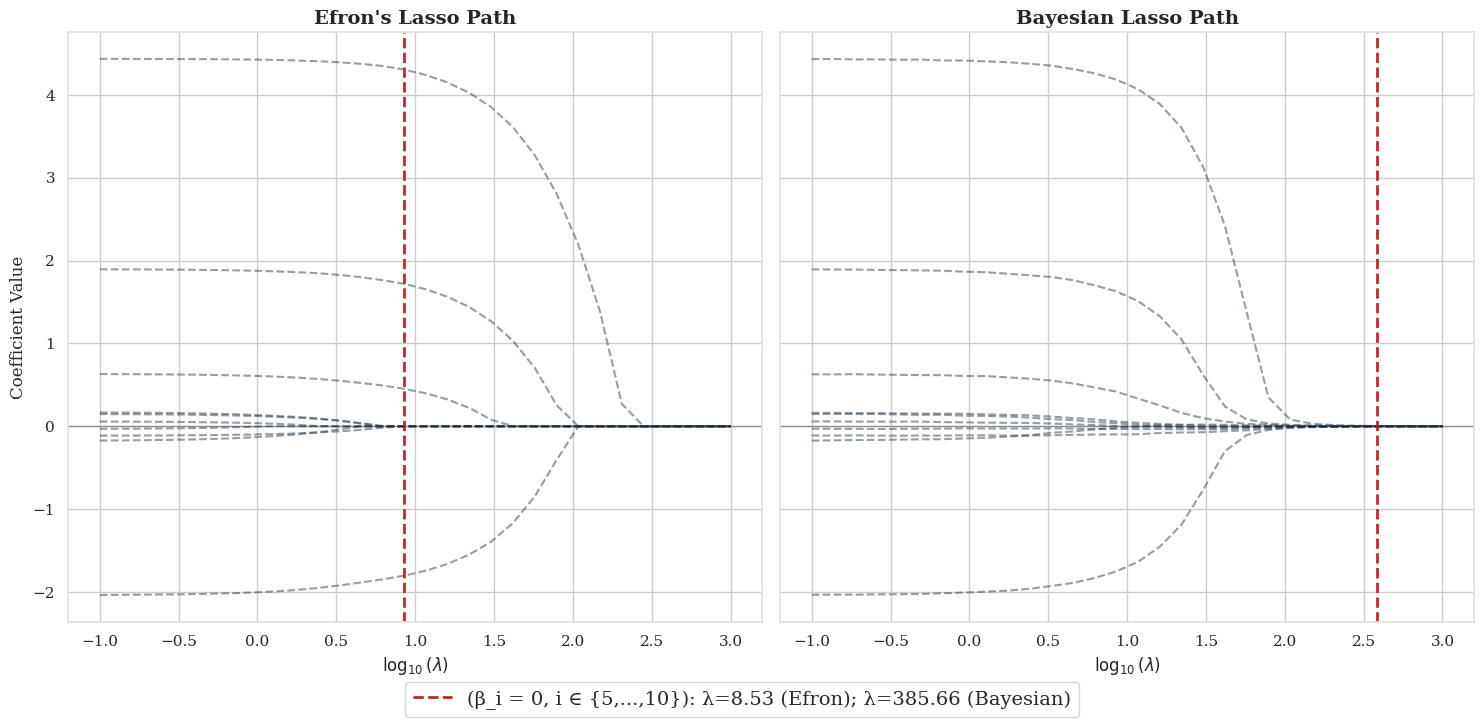

In [8]:
plot_lasso_paths(y_tilde, X)